# Telco Customer Churn Prediction

Predicting which customers are likely to churn using Logistic Regression and Neural Network.  
Comparing model performance and applying SHAP for explainability.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 21 features  
**Target:** `Churn` (Yes / No)

| Step | Description |
|------|-------------|
| 1 | Exploratory Data Analysis (EDA) |
| 2 | Preprocessing |
| 3 | Logistic Regression (Baseline) |
| 4 | Neural Network (Keras) |
| 5 | Threshold Tuning |
| 6 | SHAP — Explainable AI |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1 — Exploratory Data Analysis (EDA)

Understanding the dataset before building any model:
- How many rows and features?
- Any missing values?
- Class balance (churn vs. not churn)?
- Which features correlate most with churn?

In [2]:
# Load dataset and check basic shape
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [3]:
# Check column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Surface-level null check
# Note: hidden nulls stored as whitespace strings will NOT appear here
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# TotalCharges is object type despite being numeric
# Some rows contain ' ' (whitespace) instead of NaN — isnull() misses these
print('Hidden null rows in TotalCharges:', (df['TotalCharges'] == ' ').sum())

Hidden null rows in TotalCharges: 11


In [7]:
# Convert TotalCharges to numeric — whitespace becomes NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN with median (robust to outliers, unlike mean)
median_val = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_val)

print(f'Missing values after fix: {df["TotalCharges"].isnull().sum()}')
print(df['TotalCharges'].describe())

Missing values after fix: 0
count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


In [8]:
# Check class distribution — important for choosing the right evaluation metric
# If one class dominates, accuracy alone is misleading
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [9]:
# Temporarily encode Churn as 0/1 to compute correlation with numeric features
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()['Churn_num'].drop('Churn_num').sort_values()
print(corr)

tenure           -0.352229
TotalCharges     -0.199037
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Name: Churn_num, dtype: float64


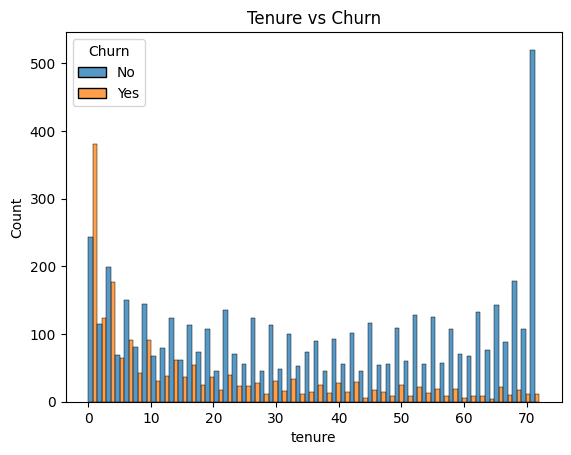

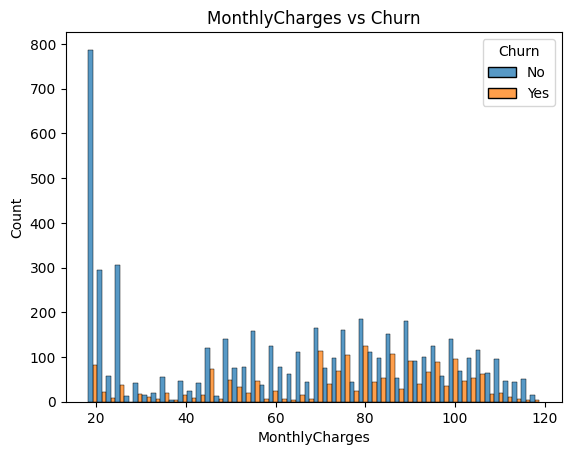

In [10]:
# Tenure: shorter tenure → higher churn rate (new customers are more likely to leave)
sns.histplot(data=df, x='tenure', hue='Churn', bins=50, multiple='dodge')
plt.title('Tenure vs Churn')
plt.show()

# MonthlyCharges: higher charges → higher churn rate (customers may feel it's not worth the cost)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=50, multiple='dodge')
plt.title('MonthlyCharges vs Churn')
plt.show()

## Step 2 — Preprocessing

Preparing raw data for model input:
- **Label Encoding** for binary columns (2 unique values — mapped to 0/1)
- **One-Hot Encoding** for multi-class columns (no ordinal relationship between categories)
- **`drop_first=True`** avoids the dummy variable trap (redundant column)
- **StandardScaler** normalizes feature scale — prevents large-value features from dominating
- **Stratified train/test split** preserves churn ratio in both train and test sets

In [11]:
# Drop columns not useful for modeling
df.drop(['customerID', 'Churn_num'], axis=1, inplace=True)

In [12]:
# Separate binary vs multi-class string columns for different encoding strategies
binary_cols = []
multi_class_cols = []
for col in df.select_dtypes(include='str').columns:
    if len(df[col].unique()) == 2:
        binary_cols.append(col)
    else:
        multi_class_cols.append(col)

print('Binary columns:', binary_cols)
print('Multi-class columns:', multi_class_cols)

Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Multi-class columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [13]:
from sklearn.preprocessing import LabelEncoder

# Binary columns → Label Encoding (0/1)
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Multi-class columns → One-Hot Encoding
# drop_first=True removes one redundant column per feature to avoid multicollinearity
df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)

print(f'Dataset shape after encoding: {df.shape}')
df.head()

Dataset shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


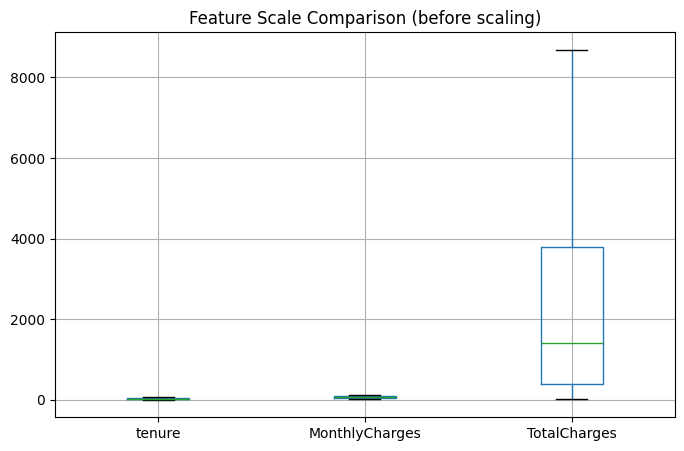

In [14]:
# Visualize scale difference before StandardScaler
# TotalCharges (0–8000) vs tenure (0–72) — without scaling, model would be biased toward larger values
df[['tenure', 'MonthlyCharges', 'TotalCharges']].boxplot(figsize=(8, 5))
plt.title('Feature Scale Comparison (before scaling)')
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

# stratify=y ensures train and test maintain the same churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# fit_transform on train only — applying train's mean/std to test prevents data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}')

Train shape: (5634, 30), Test shape: (1409, 30)
Train churn rate: 0.265, Test churn rate: 0.265


## Step 3 — Logistic Regression (Baseline)

Training a simple linear model first to establish a performance baseline.  
Any more complex model must beat these scores to justify its added complexity.

Key metrics:
- **F1 Score** — balances Precision and Recall, more reliable than accuracy on imbalanced data
- **ROC-AUC** — measures how well the model separates churn vs. not churn across all thresholds
- **Recall** — prioritized because missing a churner (FN) costs more than a false alarm (FP)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]  # probability of churn (class 1)

In [17]:
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8415846443979436


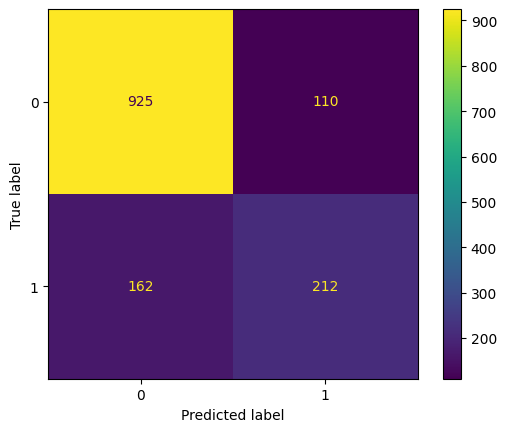

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

# FN (bottom-left): model predicted no churn but customer actually churned — most costly mistake
# FP (top-right): model predicted churn but customer stayed — results in unnecessary promotions
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## Step 4 — Neural Network (Keras)

Building a deeper model to compare against the LR baseline.

Regularization techniques to prevent overfitting:
- **L2 regularization** — penalizes large weights, forcing the model to generalize
- **Dropout (0.3)** — randomly disables 30% of neurons during each training step
- **EarlyStopping (patience=5)** — halts training if val_loss doesn't improve for 5 consecutive epochs
- **`restore_best_weights=True`** — reverts to the best epoch's weights, not the final epoch

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

model = tf.keras.Sequential([
    # Hidden layer 1: 64 neurons with L2 regularization to reduce overfitting
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],),
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),

    # Hidden layer 2: 32 neurons (narrowing down toward output)
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    # Output layer: linear activation (logits) — sigmoid handled by loss function
    # from_logits=True in BinaryCrossentropy is numerically more stable than applying sigmoid first
    layers.Dense(1, activation='linear')
])

model.summary()

/Users/klasanpetch/self-learning/AI_ML/customer_churn_prediction/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.7593 - loss: 0.5328 - val_accuracy: 0.7799 - val_loss: 0.4885
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.7739 - loss: 0.4849 - val_accuracy: 0.7817 - val_loss: 0.4803
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.7763 - loss: 0.4729 - val_accuracy: 0.7853 - val_loss: 0.4769
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.7815 - loss: 0.4623 - val_accuracy: 0.7853 - val_loss: 0.4745
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step - accuracy: 0.7868 - loss: 0.4551 - val_accuracy: 0.7888 - val_loss: 0.4702
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.7854 - loss: 0.4506 - val_accuracy: 0.7835 - val_loss: 0.4652
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - accuracy: 0.7894 - loss: 0.4431 - val_accuracy: 0.7835 - val_loss: 0.4637
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.7832 - loss: 0.4456 - 

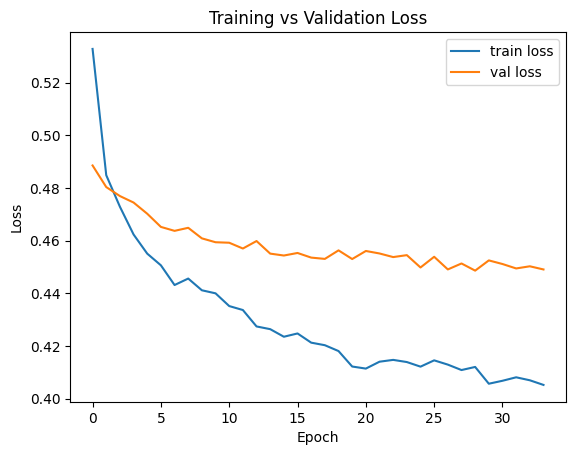

In [22]:
# If train loss keeps dropping but val loss plateaus or rises → overfitting
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [23]:
# Apply sigmoid to convert logits → probabilities before evaluation
y_prob_nn = tf.sigmoid(model.predict(X_test)).numpy().flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

print(classification_report(y_test, y_pred_nn))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_nn))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8361466325660699


## Step 5 — Threshold Tuning

By default, models classify at threshold = 0.5.  
In churn prediction, we prefer **higher Recall** — catching more churners even at the cost of some false alarms.

- **Lower threshold** → more customers flagged as churn → Recall ↑, Precision ↓
- **Higher threshold** → fewer flagged → Precision ↑, Recall ↓

> Business decision: cost of losing a customer (FN) > cost of giving an unnecessary promotion (FP)  
> → Lowering threshold from 0.5 → 0.3 increases Recall from 57% → 75%

In [24]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Compare Logistic Regression performance at different classification thresholds
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_prob > threshold).astype(int)
    print(f"Threshold {threshold}: "
          f"Precision={precision_score(y_test, y_pred_t):.2f}, "
          f"Recall={recall_score(y_test, y_pred_t):.2f}, "
          f"F1={f1_score(y_test, y_pred_t):.2f}")

Threshold 0.3: Precision=0.52, Recall=0.75, F1=0.61
Threshold 0.4: Precision=0.57, Recall=0.67, F1=0.61
Threshold 0.5: Precision=0.66, Recall=0.57, F1=0.61
Threshold 0.6: Precision=0.71, Recall=0.40, F1=0.51


## Step 6 — SHAP (Explainable AI)

SHAP explains *why* the model made each prediction — bridging model output and business decisions.

**How to read the plots:**
- **Red** = high feature value, **Blue** = low feature value
- **Right (positive SHAP value)** = pushes prediction toward churn
- **Left (negative SHAP value)** = pushes prediction away from churn

**Summary plot** — global feature importance across all customers  
**Force plot** — individual prediction breakdown for a single customer

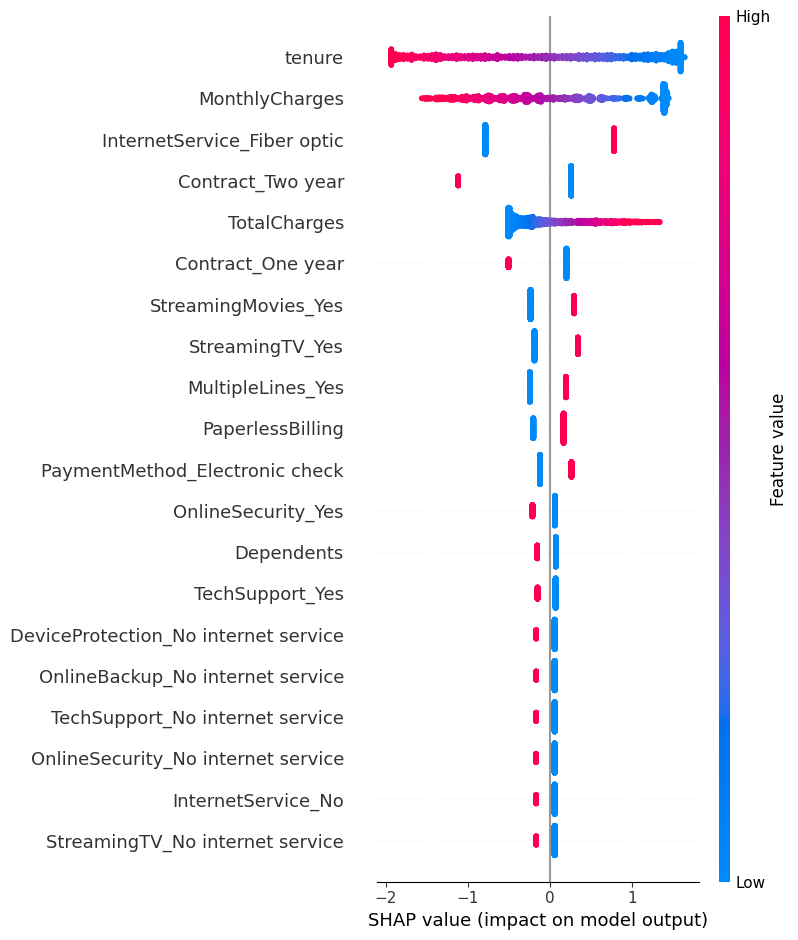

In [25]:
import shap

explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer.shap_values(X_test)

feature_names = df.drop('Churn', axis=1).columns.tolist()

# Summary plot: which features drive churn predictions the most?
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

In [26]:
# Force plot: explains a single customer's prediction
# Red arrows push toward churn, blue arrows push away from churn
# f(x) < 0 → predicted as not churn, f(x) > 0 → predicted as churn
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test[0],
    feature_names=feature_names
)

In [27]:
# A different customer — predicted as likely to churn
# Short tenure + Fiber optic + no long-term contract → high churn risk
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[1],
    X_test[1],
    feature_names=feature_names
)